# Projekt: Predikcija cijene rezervacije (Hotel Booking Demand)

**Cilj:** Izraditi regresijski model za predikciju prosječne dnevne cijene sobe (*Average Daily Rate* - ADR).

U ovom notebooku prolazimo kroz cijeli tijek analize: čišćenje podataka, obradu ekstremnih vrijednosti, eksplorativnu analizu, pripremu značajki i usporedbu dva modela.

Uklonjeni su stupci koji uzrokuju *data leakage* (`reservation_status`, `reservation_status_date`, `is_canceled`, `assigned_room_type`), a ekstremne vrijednosti su obrađene IQR metodom.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

# Učitavanje podataka
df = pd.read_csv('hotel_bookings.csv')

# Osnovni pregled
print(f'Oblik dataseta: {df.shape}')
print('\nPrvih 5 redaka:')
display(df.head())

print('\nTipovi stupaca:')
print(df.dtypes)

print('\nBroj duplikata:')
print(df.duplicated().sum())

print('\nNedostajuće vrijednosti po stupcima:')
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

print('\nDeskriptivna statistika za numeričke stupce:')
display(df.describe().T)


Oblik dataseta: (119390, 32)

Prvih 5 redaka:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03



Tipovi stupaca:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent            

company     112593
agent        16340
country        488
children         4
dtype: int64


Deskriptivna statistika za numeričke stupce:


,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


## 1. Čišćenje podataka (Data Cleaning)

U ovom koraku pripremamo skup podataka za daljnju analizu. Uklanjamo duplikate, rješavamo nedostajuće vrijednosti i pazimo da podaci budu što konzistentniji prije treniranja modela.

Stupci `agent` i `company` imaju velik broj nedostajućih vrijednosti, pa ih uklanjamo, dok se za ostale varijable koriste logične imputacije ili jednostavniji pristupi čišćenja.


In [2]:
# Uklanjanje duplikata
broj_duplikata_prije = df.duplicated().sum()
print(f'Broj duplikata prije čišćenja: {broj_duplikata_prije}')
df = df.drop_duplicates().copy()
print(f'Oblik nakon uklanjanja duplikata: {df.shape}')

# Rješavanje nedostajućih vrijednosti
# Pretpostavljamo da null u children znači 0
df['children'] = df['children'].fillna(0)

# Za državu koristimo Unknown
df['country'] = df['country'].fillna('Unknown')

# Uklanjamo stupce s previše nedostajućih vrijednosti
for col in ['agent', 'company']:
    if col in df.columns:
        df = df.drop(columns=col)

print('\nPreostale nedostajuće vrijednosti:')
missing_after = df.isna().sum().sort_values(ascending=False)
display(missing_after[missing_after > 0])


Broj duplikata prije čišćenja: 31994
Oblik nakon uklanjanja duplikata: (87396, 32)

Preostale nedostajuće vrijednosti:


Series([], dtype: int64)

## 2. Detekcija i obrada ekstremnih vrijednosti (Outliers)

Ciljna varijabla je `adr` (*Average Daily Rate*), odnosno prosječna dnevna cijena rezervacije.

Najprije uklanjamo nelogične vrijednosti poput `adr <= 0`, a zatim primjenjujemo IQR metodu kako bismo uklonili ekstremne cijene koje bi mogle narušiti kvalitetu modela i utjecati na stabilnost predikcije.


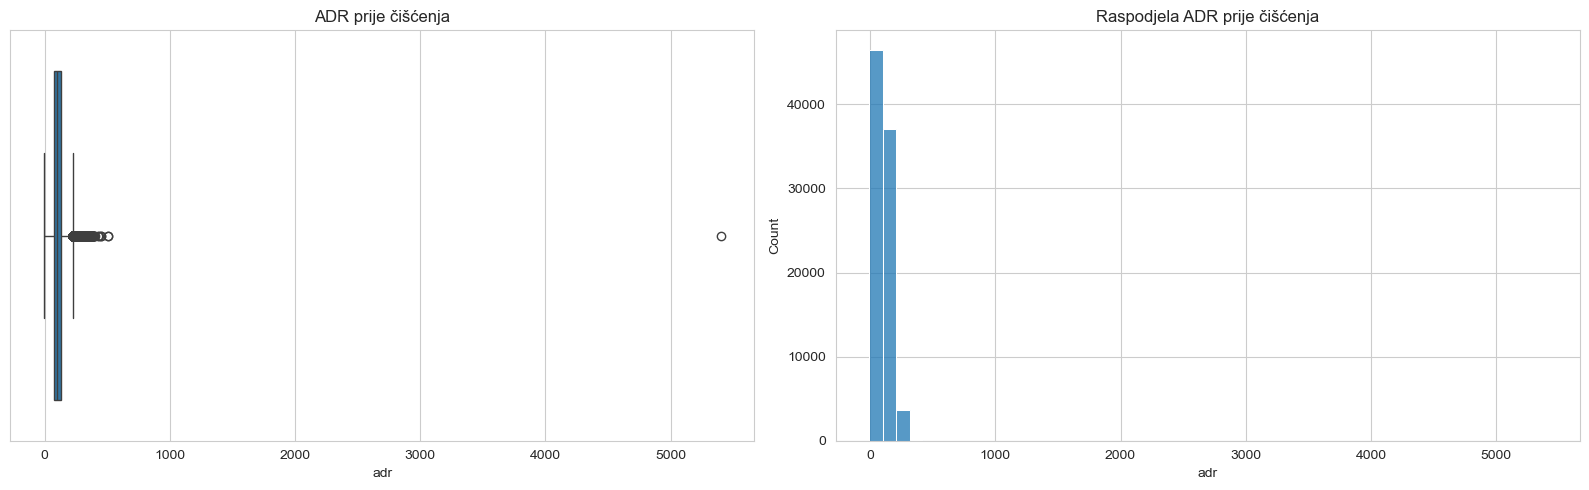

Q1: 74.46
Q3: 135.00
IQR: 60.54
Donja granica: -16.35
Gornja granica: 225.81
Uklonjeno redaka zbog outliera: 2539


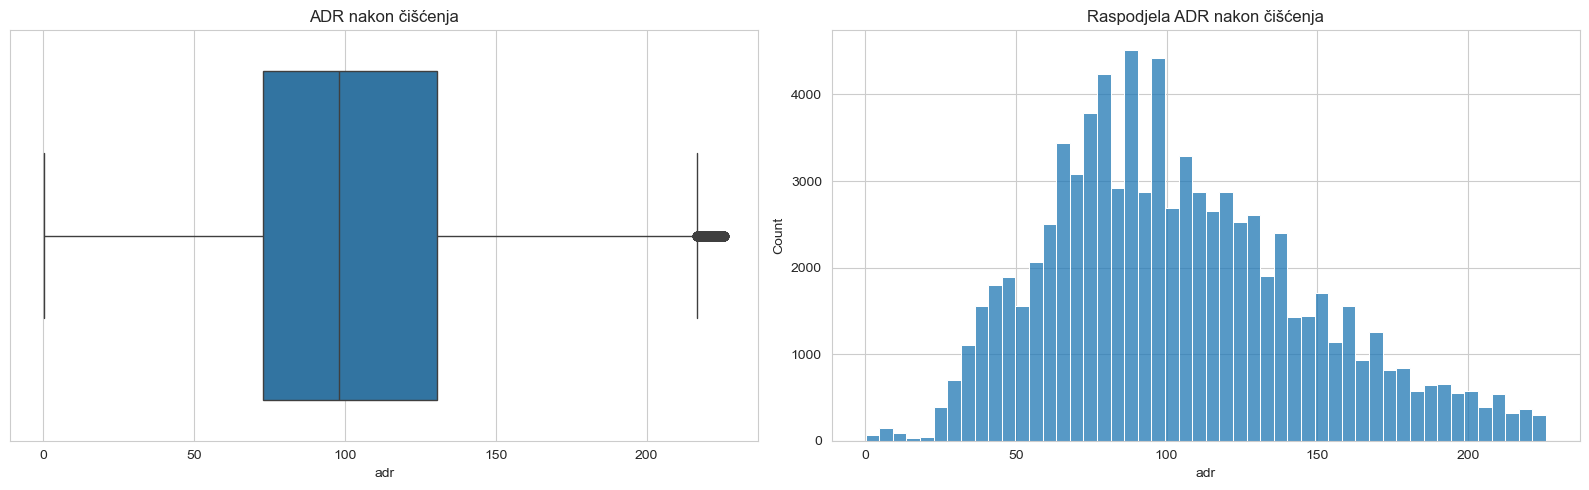

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Prije čišćenja
sns.boxplot(ax=axes[0], x=df['adr'])
axes[0].set_title('ADR prije čišćenja')
axes[0].set_xlabel('adr')

sns.histplot(ax=axes[1], data=df, x='adr', bins=50)
axes[1].set_title('Raspodjela ADR prije čišćenja')

plt.tight_layout()
plt.show()

# Čišćenje outliera
df = df[df['adr'] > 0].copy()

q1 = df['adr'].quantile(0.25)
q3 = df['adr'].quantile(0.75)
iqr = q3 - q1
donja_granica = q1 - 1.5 * iqr
gornja_granica = q3 + 1.5 * iqr

broj_redaka_prije = len(df)
df = df[(df['adr'] >= donja_granica) & (df['adr'] <= gornja_granica)].copy()
broj_redaka_nakon = len(df)

print(f'Q1: {q1:.2f}')
print(f'Q3: {q3:.2f}')
print(f'IQR: {iqr:.2f}')
print(f'Donja granica: {donja_granica:.2f}')
print(f'Gornja granica: {gornja_granica:.2f}')
print(f'Uklonjeno redaka zbog outliera: {broj_redaka_prije - broj_redaka_nakon}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(ax=axes[0], x=df['adr'])
axes[0].set_title('ADR nakon čišćenja')
axes[0].set_xlabel('adr')

sns.histplot(ax=axes[1], data=df, x='adr', bins=50)
axes[1].set_title('Raspodjela ADR nakon čišćenja')

plt.tight_layout()
plt.show()


## 3. Eksplorativna analiza podataka (EDA)

U ovom dijelu analiziramo osnovne obrasce u podacima prije modeliranja. Posebno promatramo sezonalnost cijena i odnos tipa sobe s konačnom cijenom rezervacije.

Cilj EDA dijela je bolje razumjeti što najviše utječe na cijenu i uočiti moguće veze među varijablama koje će biti korisne u kasnijoj pripremi podataka i odabiru modela.


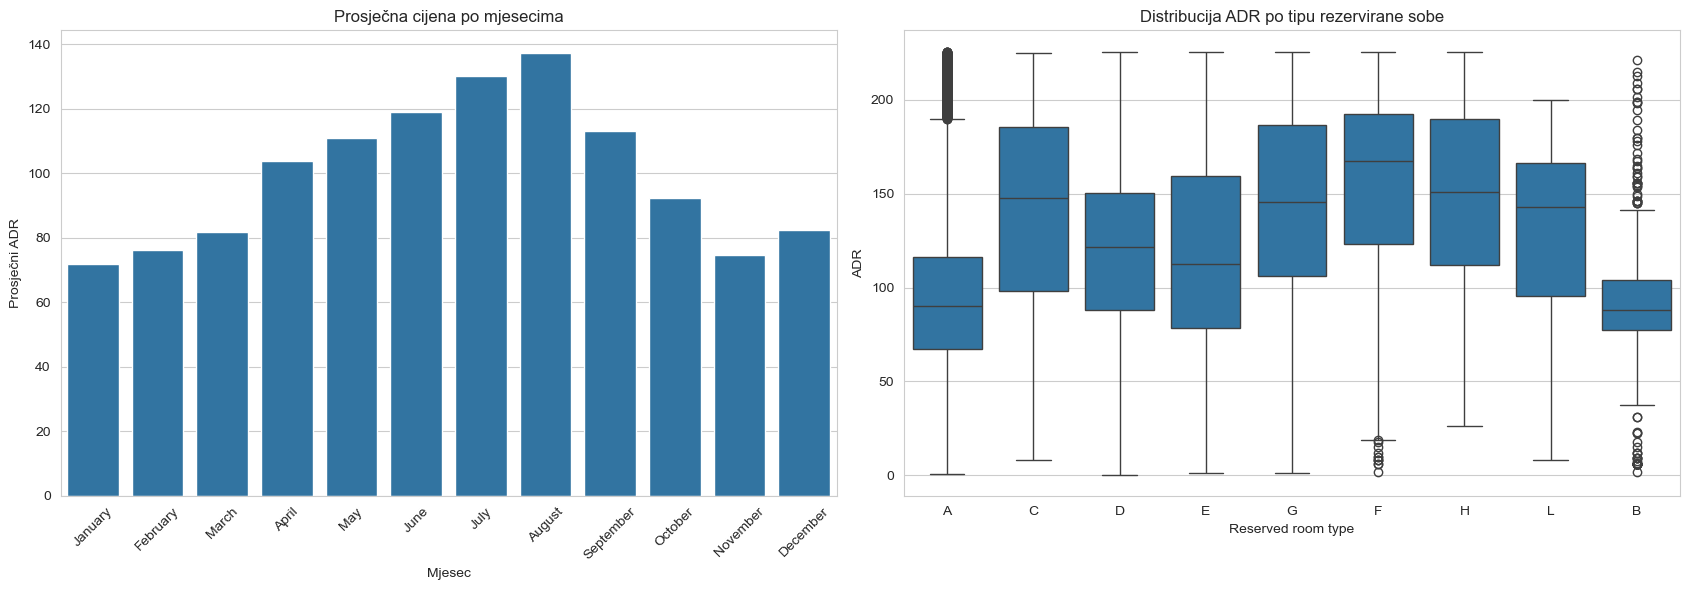

Dodatni pregled: korelacija numeričkih varijabli s ADR


,korelacija_s_adr
adr,1.000000
adults,0.323762
children,0.274692
arrival_date_year,0.159677
total_of_special_requests,0.159643
is_canceled,0.123095
arrival_date_week_number,0.106109
babies,0.020811
lead_time,0.019609
arrival_date_day_of_month,0.018331


In [4]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=month_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Prosječna cijena po mjesecima
sns.barplot(
    ax=axes[0],
    data=df,
    x='arrival_date_month',
    y='adr',
    order=month_order,
    errorbar=None
)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title('Prosječna cijena po mjesecima')
axes[0].set_xlabel('Mjesec')
axes[0].set_ylabel('Prosječni ADR')

# Cijena po tipu sobe
sns.boxplot(
    ax=axes[1],
    data=df,
    x='reserved_room_type',
    y='adr'
)
axes[1].set_title('Distribucija ADR po tipu rezervirane sobe')
axes[1].set_xlabel('Reserved room type')
axes[1].set_ylabel('ADR')

plt.tight_layout()
plt.show()

print('Dodatni pregled: korelacija numeričkih varijabli s ADR')
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr(numeric_only=True)['adr'].sort_values(ascending=False)
display(corr.to_frame('korelacija_s_adr'))


## 4. Feature Engineering i priprema podataka

U ovom koraku stvaramo nove značajke koje bolje opisuju ponašanje gostiju i rezervacija, primjerice ukupan broj gostiju ili ukupni broj noćenja.

Također uklanjamo stupce koji predstavljaju *data leakage* kako model ne bi koristio informacije koje ne bi bile dostupne u stvarnom trenutku predikcije. Na kraju pripremamo podatke za treniranje modela.


In [5]:
# 1. Novi feature-i
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Uklanjamo besmislene rezervacije bez ijednog gosta
df = df[df['total_guests'] > 0].copy()

# Pretvaranje mjeseca u broj radi lakšeg hvatanja sezonalnosti
month_to_num = {mj: i + 1 for i, mj in enumerate(month_order)}
df['arrival_date_month_num'] = df['arrival_date_month'].map(month_to_num)

# Grupiranje država: top 10 + Other
top_countries = df['country'].value_counts().nlargest(10).index
df['country_grouped'] = df['country'].apply(lambda x: x if x in top_countries else 'Other')

# 2. Odabir kategoričkih stupaca za One-Hot Encoding
# Napomena: assigned_room_type ne koristimo zbog moguće post-booking informacije
categorical_cols = [
    'hotel',
    'meal',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'country_grouped',
    'deposit_type',
    'customer_type'
]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3. Definiranje X i y
target = 'adr'
stupci_za_izbaciti = [
    'adr',
    'arrival_date_month',
    'country',
    'reservation_status',
    'reservation_status_date',
    'is_canceled',
    'assigned_room_type'
]

X = df_encoded.drop(columns=[col for col in stupci_za_izbaciti if col in df_encoded.columns])
y = df_encoded[target]

# Pretvaranje u float radi sigurnosti
X = X.astype(float)

# 4. Podjela na trening i test skup
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Oblik trening skupa X_train: {X_train.shape}')
print(f'Oblik test skupa X_test: {X_test.shape}')
print(f'Broj konačnih značajki: {X_train.shape[1]}')

print('\nPrvih nekoliko stupaca nakon pripreme:')
display(X_train.head())


Oblik trening skupa X_train: (66437, 58)
Oblik test skupa X_test: (16610, 58)
Broj konačnih značajki: 58

Prvih nekoliko stupaca nakon pripreme:


,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,...,country_grouped_IRL,country_grouped_ITA,country_grouped_NLD,country_grouped_Other,country_grouped_PRT,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
15569,72.0,2015.0,30.0,22.0,0.0,4.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
9446,132.0,2016.0,49.0,29.0,1.0,5.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
61429,74.0,2016.0,50.0,10.0,0.0,1.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
110941,9.0,2017.0,18.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
26371,66.0,2016.0,30.0,23.0,2.0,5.0,3.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## 5. Implementacija modela: Linearna regresija (baseline)

Linearna regresija služi kao početna referentna točka. Ovaj model koristimo da vidimo koliko daleko možemo doći jednostavnim linearnim odnosom između značajki i ciljne varijable.

Rezultati ovog modela kasnije se uspoređuju s naprednijim pristupom kako bismo procijenili koliko dodatna složenost stvarno poboljšava predikciju.


In [6]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print('--- LINEAR REGRESSION ---')
print(f'MAE:  {mae_lr:.2f} EUR')
print(f'RMSE: {rmse_lr:.2f} EUR')
print(f'R2:   {r2_lr:.4f}')


--- LINEAR REGRESSION ---
MAE:  24.29 EUR
RMSE: 32.31 EUR
R2:   0.4396


## 6. Napredni model: Random Forest Regressor

Random Forest je prikladan za nelinearne odnose i često daje bolje rezultate na stvarnim podacima gdje veza između varijabli nije jednostavno linearna.

Ovim modelom pokušavamo uhvatiti složenije obrasce u podacima te provjeriti može li bolje predvidjeti ADR u usporedbi s linearnom regresijom.


In [7]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print('--- RANDOM FOREST ---')
print(f'MAE:  {mae_rf:.2f} EUR')
print(f'RMSE: {rmse_rf:.2f} EUR')
print(f'R2:   {r2_rf:.4f}')


--- RANDOM FOREST ---
MAE:  11.51 EUR
RMSE: 17.18 EUR
R2:   0.8416


## 7. Vizualizacija rezultata i važnosti značajki

U ovom dijelu uspoređujemo važnost pojedinih značajki prema Random Forest modelu. Time možemo vidjeti koji atributi najviše doprinose predikciji cijene.

Vizualizacija rezultata pomaže u interpretaciji modela i daje jasniji uvid u to koji faktori imaju najveći utjecaj na konačnu procjenu cijene rezervacije.


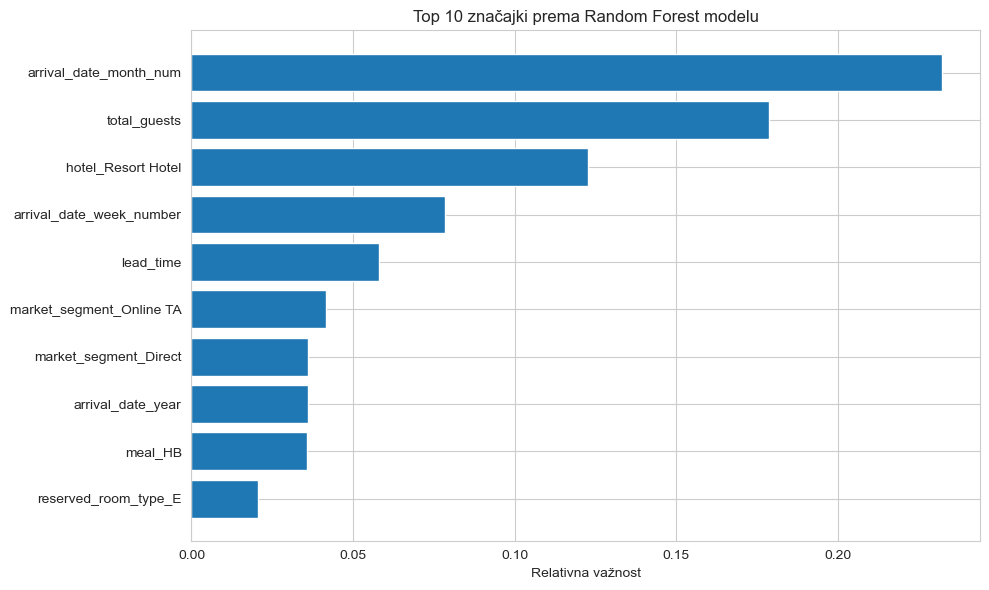


Konačna usporedba modela:


,Model,MAE (EUR),RMSE (EUR),R2 Score
0,Linear Regression,24.294512,32.306363,0.439591
1,Random Forest,11.507704,17.176523,0.841584


In [8]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
plt.barh(importances.index, importances.values)
plt.title('Top 10 značajki prema Random Forest modelu')
plt.xlabel('Relativna važnost')
plt.tight_layout()
plt.show()

usporedba = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE (EUR)': [mae_lr, mae_rf],
    'RMSE (EUR)': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})

print('\nKonačna usporedba modela:')
display(usporedba)


## 8. Zaključak i interpretacija rezultata

- Linearna regresija daje dobar baseline, ali ne hvata dovoljno nelinearnih odnosa u podacima.
- Random Forest postiže bolje rezultate i bolje opisuje odnos između sezonalnosti, tipa sobe, tržišnog segmenta i konačne cijene.
- Najvažniji korak u cijelom postupku bio je izbjegavanje *data leakage* problema, zbog čega su uklonjeni stupci `reservation_status`, `reservation_status_date`, `is_canceled` i `assigned_room_type`.


In [9]:
print(f'Linear Regression -> MAE: {mae_lr:.2f}, RMSE: {rmse_lr:.2f}, R2: {r2_lr:.4f}')
print(f'Random Forest     -> MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, R2: {r2_rf:.4f}')

Linear Regression -> MAE: 24.29, RMSE: 32.31, R2: 0.4396
Random Forest     -> MAE: 11.51, RMSE: 17.18, R2: 0.8416
